# Cleaning the NYC Parking Violations Source Data

This notebook documents the first major step in the NYC Parking Analytics project: importing, inspecting, cleaning, and exporting the original `nycparking2025.csv` file.

The goal is to create a reliable, analysis-ready parking violations dataset that can later be joined to weather data, violation fine data, and census data.

## Why this notebook matters

The original parking file is large and contains more columns than are needed for the project. Before loading the data into SQLite or building visualizations, I need to:

- keep only the columns that support the analysis questions,
- standardize column names,
- convert dates and numeric columns to usable data types,
- handle missing and invalid values,
- remove duplicate ticket records,
- create useful derived fields for analysis,
- write the cleaned output to `data/processed/parking_clean.csv`.

Because the file is large, the final cleaning step is designed to process the data in chunks instead of loading the entire file into memory at once.

## Analysis questions supported by this cleaned dataset

This cleaned parking data will support questions such as:

1. How do NYC parking violations change over time by month and day of week?
2. Which violation types and precincts account for the most tickets?
3. Which violations create the largest estimated fine exposure after joining to the fine lookup?
4. Are certain weather conditions associated with higher or lower ticket volume after joining to weather data?
5. How do ticket counts compare across boroughs or counties after adding census context?

In [ ]:
from __future__ import annotations
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

## File paths

All paths are relative to the project root so the notebook works across operating systems as long as it is run from the project folder.

- Raw source: `data/raw/nycparking2025.csv`
- Cleaned output: `data/processed/parking_clean.csv`

The original source file is intentionally not committed to Git because it is very large. The cleaning logic in this notebook makes the project reproducible.

In [ ]:
STARTING_DIR = Path.cwd()
PROJECT_ROOT = STARTING_DIR

if not (PROJECT_ROOT / "data" / "raw" / "nycparking2025.csv").exists():
    PROJECT_ROOT = STARTING_DIR.parent

RAW_FILE = PROJECT_ROOT / "data" / "raw" / "nycparking2025.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLEAN_FILE = PROCESSED_DIR / "parking_clean.csv"

if not RAW_FILE.exists():
    raise FileNotFoundError(f"Could not find the source file at {RAW_FILE}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw source: {RAW_FILE}")
print(f"Clean output: {CLEAN_FILE}")

Project root: c:\Users\jayson.coker\Documents\nyc-parking-analytics
Raw source: c:\Users\jayson.coker\Documents\nyc-parking-analytics\data\raw\nycparking2025.csv
Clean output: c:\Users\jayson.coker\Documents\nyc-parking-analytics\data\processed\parking_clean.csv


## Step 1: Inspect the source file before cleaning

Before changing the data, I first inspect the file size, number of rows, and column names. This confirms that I am working with the original source and helps identify columns needed for the final analysis.

In [ ]:
def count_csv_rows(path: Path) -> int:
    """Count data rows in a CSV without loading the full file into memory."""
    line_count = 0
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            line_count += chunk.count(b"\n")
    return max(line_count - 1, 0)


def read_csv_header(path: Path) -> list[str]:
    """Read only the header row from a CSV file."""
    with path.open("r", encoding="utf-8-sig", newline="", errors="replace") as file:
        return next(csv.reader(file))


source_rows = count_csv_rows(RAW_FILE)
source_columns = read_csv_header(RAW_FILE)

print(f"Source file size: {RAW_FILE.stat().st_size / 1024 / 1024:,.2f} MB")
print(f"Source data rows: {source_rows:,}")
print(f"Source columns: {len(source_columns)}")
source_columns

Source file size: 1,249.99 MB
Source data rows: 7,057,514
Source columns: 43


['Summons Number',
 'Plate ID',
 'Registration State',
 'Plate Type',
 'Issue Date',
 'Violation Code',
 'Vehicle Body Type',
 'Vehicle Make',
 'Issuing Agency',
 'Street Code1',
 'Street Code2',
 'Street Code3',
 'Vehicle Expiration Date',
 'Violation Location',
 'Violation Precinct',
 'Issuer Precinct',
 'Issuer Code',
 'Issuer Command',
 'Issuer Squad',
 'Violation Time',
 'Time First Observed',
 'Violation County',
 'Violation In Front Of Or Opposite',
 'House Number',
 'Street Name',
 'Intersecting Street',
 'Date First Observed',
 'Law Section',
 'Sub Division',
 'Violation Legal Code',
 'Days Parking In Effect',
 'From Hours In Effect',
 'To Hours In Effect',
 'Vehicle Color',
 'Unregistered Vehicle?',
 'Vehicle Year',
 'Meter Number',
 'Feet From Curb',
 'Violation Post Code',
 'Violation Description',
 'No Standing or Stopping Violation',
 'Hydrant Violation',
 'Double Parking Violation']

## Step 2: Load a sample for profiling

The source file has millions of rows, so I start with a sample. The sample lets me inspect data types, missing values, duplicates, and common values quickly before running the full chunked cleaning process.

In [ ]:
SAMPLE_ROWS = 100_000

sample = pd.read_csv(RAW_FILE, nrows=SAMPLE_ROWS, low_memory=False, dtype=str)
sample.head()

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,Street Code2,Street Code3,Vehicle Expiration Date,Violation Location,Violation Precinct,Issuer Precinct,Issuer Code,Issuer Command,Issuer Squad,Violation Time,Time First Observed,Violation County,Violation In Front Of Or Opposite,House Number,Street Name,Intersecting Street,Date First Observed,Law Section,Sub Division,Violation Legal Code,Days Parking In Effect,From Hours In Effect,To Hours In Effect,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
0,9139716661,LKS7820,NY,PAS,07/02/2024,38,SUBN,TOYOT,T,26790,28590,12810,20260312,5,5,5,363518,T105,J,0209P,NaN,NY,F,42A,Mott St,NaN,0,408,H1,NaN,YYYYYY,0730A,1000P,WH,NaN,2024,100038,0,71,38-Failure to Dsplay Meter Rec,NaN,NaN,NaN
1,4903865265,Y23UMS,NJ,PAS,06/21/2024,36,VAN,ME/BE,V,0,40404,40404,0,NaN,0,0,0,NaN,NaN,1009A,NaN,BK,NaN,NaN,NB UTICA AVE @ AVE L,NaN,0,1180,B,T,NaN,NaN,NaN,NaN,NaN,2024,NaN,0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,NaN,NaN,NaN
2,9140510268,N76NJN,NJ,PAS,07/08/2024,14,SUBN,HYUND,T,24890,17910,17930,88888888,18,18,18,356484,T106,H,0325P,NaN,NY,F,485,Lexington Ave,NaN,0,408,C,NaN,YYYYYYY,NaN,NaN,WHITE,NaN,0,NaN,0,12,14-No Standing,NaN,NaN,NaN
3,9136561575,42UD91,NY,MCL,07/12/2024,71,MCY,HONDA,T,47030,58730,85730,20240430,79,79,79,376215,T301,G,0939A,NaN,K,F,252,Hancock St,NaN,0,408,J6,NaN,YYYYYYY,NaN,NaN,BLACK,NaN,0,NaN,0,9,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN
4,9139621832,76925NE,NY,COM,07/11/2024,14,VAN,ISUZU,T,51090,64790,23070,20260228,103,103,103,370871,T402,O,1116A,NaN,Q,F,147-21,Jamaica Ave,NaN,0,408,C,NaN,YYYYYYY,NaN,NaN,WH,NaN,2018,NaN,0,12,14-No Standing,NaN,NaN,NaN


In [ ]:
sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                             Non-Null Count   Dtype
---  ------                             --------------   -----
 0   Summons Number                     100000 non-null  str  
 1   Plate ID                           99995 non-null   str  
 2   Registration State                 100000 non-null  str  
 3   Plate Type                         100000 non-null  str  
 4   Issue Date                         99993 non-null   str  
 5   Violation Code                     100000 non-null  str  
 6   Vehicle Body Type                  99729 non-null   str  
 7   Vehicle Make                       99891 non-null   str  
 8   Issuing Agency                     100000 non-null  str  
 9   Street Code1                       100000 non-null  str  
 10  Street Code2                       100000 non-null  str  
 11  Street Code3                       100000 non-null  str  
 12  Vehicle Expira

## Step 3: Choose the columns needed for analysis

The original file contains 43 columns. I do not need every column for the final project. I keep columns that support time analysis, location analysis, violation type analysis, vehicle context, and later joins.

The selected columns include:

- `Summons Number`: unique ticket identifier and duplicate check field
- `Issue Date`: required for time trends and weather joins
- `Violation Code`: required for joining to the fine lookup
- `Violation Description`: readable meaning of each violation
- `Violation Precinct` and `Issuer Precinct`: location and enforcement context
- `Violation County`: used to create borough/county context for census joins
- vehicle and street fields that can support descriptive analysis

In [ ]:
SOURCE_COLUMNS = {
    "Summons Number": "summons_number",
    "Plate ID": "plate_id",
    "Registration State": "registration_state",
    "Plate Type": "plate_type",
    "Issue Date": "issue_date",
    "Violation Code": "violation_code",
    "Vehicle Body Type": "vehicle_body_type",
    "Vehicle Make": "vehicle_make",
    "Issuing Agency": "issuing_agency",
    "Violation Precinct": "violation_precinct",
    "Issuer Precinct": "issuer_precinct",
    "Violation Time": "violation_time",
    "Violation County": "violation_county",
    "Street Name": "street_name",
    "Vehicle Color": "vehicle_color",
    "Vehicle Year": "vehicle_year",
    "Violation Description": "violation_description",
}

OUTPUT_COLUMNS = list(SOURCE_COLUMNS.values()) + [
    "issue_year",
    "issue_month",
    "issue_day_of_week",
    "issue_day_name",
    "borough",
]

MIN_ISSUE_DATE = pd.Timestamp("2000-01-01")
MAX_ISSUE_DATE = pd.Timestamp("2025-12-31")

missing_source_columns = [column for column in SOURCE_COLUMNS if column not in source_columns]
missing_source_columns

[]

## Step 4: Profile missing values in the selected columns

Missing values matter because they can affect joins, grouping, and charts. For example:

- Missing `Issue Date` means the ticket cannot be joined to weather or used in time analysis.
- Missing `Violation Code` means the ticket cannot be joined to the fine lookup.
- Missing county or precinct values limit location analysis.

In [ ]:
def missing_value_report(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Return missing counts and percentages for selected columns."""
    report = df[columns].isna().sum().reset_index()
    report.columns = ["column", "missing_count"]
    report["missing_percent"] = (report["missing_count"] / len(df) * 100).round(2)
    return report.sort_values("missing_percent", ascending=False)


selected_sample = sample[list(SOURCE_COLUMNS)].rename(columns=SOURCE_COLUMNS)
missing_value_report(selected_sample, list(SOURCE_COLUMNS.values()))

,column,missing_count,missing_percent
14,vehicle_color,11027,11.03
16,violation_description,1847,1.85
12,violation_county,844,0.84
6,vehicle_body_type,271,0.27
7,vehicle_make,109,0.11
4,issue_date,7,0.01
13,street_name,10,0.01
0,summons_number,0,0.00
1,plate_id,5,0.00
8,issuing_agency,0,0.00


## Step 5: Define cleaning rules

The cleaning rules are designed to keep the dataset useful for analysis while avoiding unnecessary data loss.

Cleaning decisions:

1. Rename columns to snake_case so they are easier to use in Python and SQL.
2. Parse `Issue Date` into a real date.
3. Remove rows with invalid, missing, or unrealistic issue dates outside January 1, 2000 through December 31, 2025 because they cannot support reliable time analysis or weather joins.
4. Convert numeric fields such as summons number, violation code, precincts, and vehicle year.
5. Remove rows with missing summons number because that is the ticket identifier.
6. Remove duplicate summons numbers, keeping the first record.
7. Standardize text fields by trimming whitespace and replacing empty strings with missing values.
8. Create date fields that make analysis easier: year, month, day of week, and day name.
9. Map NYC county codes/names to boroughs when possible.

In [ ]:
BOROUGH_MAP = {
    "BRONX": "Bronx",
    "BX": "Bronx",
    "P": "Bronx",
    "108": "Bronx",
    "BK": "Brooklyn",
    "K": "Brooklyn",
    "K F": "Brooklyn",
    "KINGS": "Brooklyn",
    "Q": "Queens",
    "QN": "Queens",
    "QNS": "Queens",
    "MN": "Manhattan",
    "NY": "Manhattan",
    "R": "Staten Island",
    "RICH": "Staten Island",
    "ST": "Staten Island",
}


def normalize_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip whitespace from text columns and convert blank strings to missing values."""
    text_columns = df.select_dtypes(include=["object", "string"]).columns
    for column in text_columns:
        df[column] = df[column].astype("string").str.strip()
        df[column] = df[column].replace("", pd.NA)
    return df


def map_borough(county_value) -> str | pd.NA:
    """Map NYC parking county codes/names to borough names where possible."""
    if pd.isna(county_value):
        return pd.NA
    key = " ".join(str(county_value).upper().split())
    return BOROUGH_MAP.get(key, pd.NA)


def clean_parking_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Clean one chunk of the NYC parking violations source file."""
    chunk = chunk[list(SOURCE_COLUMNS)].rename(columns=SOURCE_COLUMNS).copy()
    chunk = normalize_text_columns(chunk)

    chunk["issue_date"] = pd.to_datetime(chunk["issue_date"], format="%m/%d/%Y", errors="coerce")
    valid_date = chunk["issue_date"].between(MIN_ISSUE_DATE, MAX_ISSUE_DATE)
    chunk = chunk.loc[valid_date].copy()

    numeric_columns = [
        "summons_number",
        "violation_code",
        "violation_precinct",
        "issuer_precinct",
        "vehicle_year",
    ]
    for column in numeric_columns:
        chunk[column] = pd.to_numeric(chunk[column], errors="coerce")

    chunk = chunk.dropna(subset=["summons_number"])
    chunk["summons_number"] = chunk["summons_number"].astype("int64")

    chunk["issue_year"] = chunk["issue_date"].dt.year
    chunk["issue_month"] = chunk["issue_date"].dt.month
    chunk["issue_day_of_week"] = chunk["issue_date"].dt.dayofweek
    chunk["issue_day_name"] = chunk["issue_date"].dt.day_name()
    chunk["borough"] = chunk["violation_county"].map(map_borough)
    chunk["issue_date"] = chunk["issue_date"].dt.strftime("%Y-%m-%d")

    return chunk[OUTPUT_COLUMNS]

## Step 6: Test the cleaning logic on the sample

Before cleaning the full file, I test the cleaning function on the sample. This verifies the column names, data type conversions, derived fields, and borough mapping.

In [ ]:
clean_sample = clean_parking_chunk(sample)
clean_sample.head()

,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,violation_precinct,issuer_precinct,violation_time,violation_county,street_name,vehicle_color,vehicle_year,violation_description,issue_year,issue_month,issue_day_of_week,issue_day_name,borough
0,9139716661,LKS7820,NY,PAS,2024-07-02,38,SUBN,TOYOT,T,5,5,0209P,NY,Mott St,WH,2024,38-Failure to Dsplay Meter Rec,2024,7,1,Tuesday,Manhattan
1,4903865265,Y23UMS,NJ,PAS,2024-06-21,36,VAN,ME/BE,V,0,0,1009A,BK,NB UTICA AVE @ AVE L,<NA>,2024,PHTO SCHOOL ZN SPEED VIOLATION,2024,6,4,Friday,Brooklyn
2,9140510268,N76NJN,NJ,PAS,2024-07-08,14,SUBN,HYUND,T,18,18,0325P,NY,Lexington Ave,WHITE,0,14-No Standing,2024,7,0,Monday,Manhattan
3,9136561575,42UD91,NY,MCL,2024-07-12,71,MCY,HONDA,T,79,79,0939A,K,Hancock St,BLACK,0,71A-Insp Sticker Expired (NYS),2024,7,4,Friday,Brooklyn
4,9139621832,76925NE,NY,COM,2024-07-11,14,VAN,ISUZU,T,103,103,1116A,Q,Jamaica Ave,WH,2018,14-No Standing,2024,7,3,Thursday,Queens


In [ ]:
clean_sample.info()

<class 'pandas.DataFrame'>
Index: 99992 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   summons_number         99992 non-null  int64 
 1   plate_id               99987 non-null  string
 2   registration_state     99992 non-null  string
 3   plate_type             99992 non-null  string
 4   issue_date             99992 non-null  str   
 5   violation_code         99992 non-null  Int64 
 6   vehicle_body_type      99722 non-null  string
 7   vehicle_make           99883 non-null  string
 8   issuing_agency         99992 non-null  string
 9   violation_precinct     99992 non-null  Int64 
 10  issuer_precinct        99992 non-null  Int64 
 11  violation_time         99990 non-null  string
 12  violation_county       99148 non-null  string
 13  street_name            99982 non-null  string
 14  vehicle_color          88965 non-null  string
 15  vehicle_year           99992 non-nu

## Step 7: Sample EDA after cleaning

These checks demonstrate that the cleaned fields are useful for analysis. They also help identify whether the cleaning logic is producing reasonable results before running on the full file.

In [ ]:
clean_sample[["issue_year", "issue_month", "violation_code", "violation_precinct", "issuer_precinct", "vehicle_year"]].describe().T

,count,mean,std,min,25%,50%,75%,max
issue_year,99992.0,2023.99981,0.076619,2000.0,2024.0,2024.0,2024.0,2025.0
issue_month,99992.0,6.785943,0.413496,1.0,7.0,7.0,7.0,11.0
violation_code,99992.0,33.283413,17.301241,0.0,21.0,36.0,36.0,99.0
violation_precinct,99992.0,27.837467,38.828249,0.0,0.0,0.0,52.0,163.0
issuer_precinct,99992.0,25.848538,48.99088,0.0,0.0,0.0,44.0,985.0
vehicle_year,99992.0,1699.867659,734.281877,0.0,2009.0,2017.0,2021.0,2068.0


In [ ]:
clean_sample["borough"].value_counts(dropna=False)

borough
Queens           30012
Brooklyn         26653
Manhattan        23554
Bronx            13969
Staten Island     4960
NaN                844
Name: count, dtype: int64

## There are 844 missing values in the borough column. I am going to use the NYC GeoSearch api to look up the missing borough by address or street. 

In [ ]:
import time
import requests

missing_boroughs = clean_sample.loc[
    clean_sample["borough"].isna()
].copy()

# House Number was not retained in clean_sample, but the original indexes remain.
missing_boroughs["house_number"] = sample.loc[
    missing_boroughs.index, "House Number"
]

missing_boroughs["lookup_address"] = (
    missing_boroughs["house_number"].fillna("").str.strip()
    + " "
    + missing_boroughs["street_name"].fillna("").str.strip()
    + ", New York, NY"
).str.strip()

display(
    missing_boroughs[
        [
            "summons_number",
            "house_number",
            "street_name",
            "violation_precinct",
            "violation_county",
            "lookup_address",
        ]
    ].head(20)
)

,summons_number,house_number,street_name,violation_precinct,violation_county,lookup_address
7,5604629856,NaN,NB Webster Ave @ E 1,0,<NA>,"NB Webster Ave @ E 1, New York, NY"
86,5604553130,NaN,EB E Fordham Rd @ Va,0,<NA>,"EB E Fordham Rd @ Va, New York, NY"
158,5135876807,NaN,NARROWS RD S (E/B) @,0,<NA>,"NARROWS RD S (E/B) @, New York, NY"
162,5604648383,NaN,EB W 178th St @ Fort,0,<NA>,"EB W 178th St @ Fort, New York, NY"
414,1493254200,1225,FULTON ST,7,<NA>,"1225 FULTON ST, New York, NY"
800,1495141895,194-176,E 128 ST,25,<NA>,"194-176 E 128 ST, New York, NY"
1192,5604569653,NaN,EB E 149th St @ Broo,0,<NA>,"EB E 149th St @ Broo, New York, NY"
1225,5604663669,NaN,NB Webster Ave @ E 1,0,<NA>,"NB Webster Ave @ E 1, New York, NY"
1232,5604617738,NaN,EB E Fordham Rd @ El,0,<NA>,"EB E Fordham Rd @ El, New York, NY"
1266,5604639760,NaN,NB Webster Ave @ E 1,0,<NA>,"NB Webster Ave @ E 1, New York, NY"


In [ ]:
""" missing_boroughs["matched_address"] = (
    missing_boroughs["matched_address"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(missing_boroughs["lookup_address"])
) """

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\jayson.coker\AppData\Local\Temp\ipykernel_25024\2264107856.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  .replace(r"^\s*$", pd.NA, regex=True)


' missing_boroughs["matched_address"] = (\n    missing_boroughs["matched_address"]\n    .replace(r"^\\s*$", pd.NA, regex=True)\n    .fillna(missing_boroughs["lookup_address"])\n) '

## Displaying the output so that I can verify that the data copied over like it should.

In [ ]:
""" display(
    missing_boroughs[
        ["lookup_address", "matched_address", "suggested_borough", "lookup_status"]
    ]
) """

' display(\n    missing_boroughs[\n        ["lookup_address", "matched_address", "suggested_borough", "lookup_status"]\n    ]\n) '

In [ ]:
GEOCODER_URL = "https://geosearch.planninglabs.nyc/v2/search"
session = requests.Session()


def lookup_nyc_address(address):
    # Avoid unreliable searches that only contain a street name.
    first_part = address.split(",")[0].strip()
    if not first_part or not any(character.isdigit() for character in first_part):
        return {
            "suggested_borough": None,
            "confidence": None,
            "matched_address": None,
            "lookup_status": "insufficient address",
        }

    try:
        response = session.get(
            GEOCODER_URL,
            params={"text": address},
            timeout=15,
        )
        response.raise_for_status()

        features = response.json().get("features", [])

        if not features:
            return {
                "suggested_borough": None,
                "confidence": None,
                "matched_address": None,
                "lookup_status": "no match",
            }

        properties = features[0]["properties"]

        return {
            "suggested_borough": properties.get("borough"),
            "confidence": properties.get("confidence"),
            "matched_address": properties.get("label"),
            "lookup_status": "matched",
        }

    except requests.RequestException as error:
        return {
            "suggested_borough": None,
            "confidence": None,
            "matched_address": None,
            "lookup_status": str(error),
        }

In [ ]:
unique_addresses = missing_boroughs["lookup_address"].dropna().unique()

lookup_cache = {}

for number, address in enumerate(unique_addresses, start=1):
    lookup_cache[address] = lookup_nyc_address(address)

    if number % 25 == 0:
        print(f"Looked up {number:,} of {len(unique_addresses):,} addresses")

    time.sleep(0.1)

Looked up 25 of 301 addresses
Looked up 50 of 301 addresses
Looked up 75 of 301 addresses
Looked up 100 of 301 addresses
Looked up 125 of 301 addresses
Looked up 150 of 301 addresses
Looked up 175 of 301 addresses
Looked up 200 of 301 addresses
Looked up 225 of 301 addresses
Looked up 250 of 301 addresses
Looked up 275 of 301 addresses
Looked up 300 of 301 addresses


In [ ]:
lookup_results = (
    missing_boroughs["lookup_address"]
    .map(lookup_cache)
    .apply(pd.Series)
)

# Assignment works whether these columns already exist or not.
missing_boroughs[lookup_results.columns] = lookup_results

display(
    missing_boroughs[
        [
            "summons_number",
            "lookup_address",
            "suggested_borough",
            "confidence",
            "matched_address",
            "lookup_status",
        ]
    ].sort_values("confidence", ascending=False)
)

,summons_number,lookup_address,suggested_borough,confidence,matched_address,lookup_status
5714,1472122045,"298 CLASSON, New York, NY",Brooklyn,1.0,"298 CLASSON AVENUE, Brooklyn, NY, USA",matched
11322,1495224545,"310 WEST 55, New York, NY",Manhattan,1.0,"310 WEST 55 STREET, New York, NY, USA",matched
15709,1495626271,"1448 , New York, NY",Manhattan,1.0,"1448 BROADWAY, New York, NY, USA",matched
23351,1495818690,"702 ROGERS, New York, NY",Brooklyn,1.0,"702 ROGERS AVENUE, Brooklyn, NY, USA",matched
18643,1490666930,"1601 BWAY, New York, NY",Manhattan,1.0,"1601 B'WAY, New York, NY, USA",matched
...,...,...,...,...,...,...
99367,5604542386,"NB Webster Ave @ E 1, New York, NY",NaN,NaN,NaN,no match
99475,5604600039,"NB Webster Ave @ E 1, New York, NY",NaN,NaN,NaN,no match
99567,5604563250,"EB W Fordham Rd @ Gr, New York, NY",NaN,NaN,NaN,insufficient address
99608,5604617301,"EB E Fordham Rd @ Wa, New York, NY",NaN,NaN,NaN,insufficient address


In [ ]:
missing_boroughs["address_for_review"] = (
    missing_boroughs["matched_address"]
    .astype("string")
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(missing_boroughs["lookup_address"].astype("string"))
)

display(
    missing_boroughs[
        [
            "lookup_address",
            "matched_address",
            "address_for_review",
            "suggested_borough",
            "confidence",
            "lookup_status",
        ]
    ]
)

,lookup_address,matched_address,address_for_review,suggested_borough,confidence,lookup_status
7,"NB Webster Ave @ E 1, New York, NY",NaN,"NB Webster Ave @ E 1, New York, NY",NaN,NaN,no match
86,"EB E Fordham Rd @ Va, New York, NY",NaN,"EB E Fordham Rd @ Va, New York, NY",NaN,NaN,insufficient address
158,"NARROWS RD S (E/B) @, New York, NY",NaN,"NARROWS RD S (E/B) @, New York, NY",NaN,NaN,insufficient address
162,"EB W 178th St @ Fort, New York, NY",NaN,"EB W 178th St @ Fort, New York, NY",NaN,NaN,no match
414,"1225 FULTON ST, New York, NY","1225 FULTON STREET, Brooklyn, NY, USA","1225 FULTON STREET, Brooklyn, NY, USA",Brooklyn,0.8,matched
...,...,...,...,...,...,...
99375,"79 TYSEN ST, New York, NY","79 TYSEN STREET, Staten Island, NY, USA","79 TYSEN STREET, Staten Island, NY, USA",Staten Island,0.8,matched
99475,"NB Webster Ave @ E 1, New York, NY",NaN,"NB Webster Ave @ E 1, New York, NY",NaN,NaN,no match
99567,"EB W Fordham Rd @ Gr, New York, NY",NaN,"EB W Fordham Rd @ Gr, New York, NY",NaN,NaN,insufficient address
99608,"EB E Fordham Rd @ Wa, New York, NY",NaN,"EB E Fordham Rd @ Wa, New York, NY",NaN,NaN,insufficient address


In [ ]:
display(
    missing_boroughs[
        ["lookup_address", "matched_address", "suggested_borough", "lookup_status"]
    ]
)

,lookup_address,matched_address,suggested_borough,lookup_status
7,"NB Webster Ave @ E 1, New York, NY",NaN,NaN,no match
86,"EB E Fordham Rd @ Va, New York, NY",NaN,NaN,insufficient address
158,"NARROWS RD S (E/B) @, New York, NY",NaN,NaN,insufficient address
162,"EB W 178th St @ Fort, New York, NY",NaN,NaN,no match
414,"1225 FULTON ST, New York, NY","1225 FULTON STREET, Brooklyn, NY, USA",Brooklyn,matched
...,...,...,...,...
99375,"79 TYSEN ST, New York, NY","79 TYSEN STREET, Staten Island, NY, USA",Staten Island,matched
99475,"NB Webster Ave @ E 1, New York, NY",NaN,NaN,no match
99567,"EB W Fordham Rd @ Gr, New York, NY",NaN,NaN,insufficient address
99608,"EB E Fordham Rd @ Wa, New York, NY",NaN,NaN,insufficient address


In [ ]:
high_confidence = missing_boroughs[
    missing_boroughs["suggested_borough"].notna()
    & missing_boroughs["confidence"].ge(0.60)
]

print(f"Missing borough rows: {len(missing_boroughs):,}")
print(f"High-confidence matches: {len(high_confidence):,}")

display(high_confidence.head(30))

Missing borough rows: 844
High-confidence matches: 222


,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,violation_precinct,issuer_precinct,violation_time,violation_county,street_name,vehicle_color,vehicle_year,violation_description,issue_year,issue_month,issue_day_of_week,issue_day_name,borough,house_number,lookup_address,suggested_borough,confidence,matched_address,lookup_status,address_for_review
414,1493254200,JJG,NY,PAS,2024-06-08,46,SDN,ME/BE,P,7,79,1000P,<NA>,FULTON ST,WH,2024,<NA>,2024,6,5,Saturday,NaN,1225,"1225 FULTON ST, New York, NY",Brooklyn,0.8,"1225 FULTON STREET, Brooklyn, NY, USA",matched,"1225 FULTON STREET, Brooklyn, NY, USA"
800,1495141895,LJW5169,NY,PAS,2024-06-11,50,SUBN,VOLKS,P,25,25,1227P,<NA>,E 128 ST,GREY,2024,<NA>,2024,6,1,Tuesday,NaN,194-176,"194-176 E 128 ST, New York, NY",Manhattan,0.8,"176 EAST 128 STREET, New York, NY, USA",matched,"176 EAST 128 STREET, New York, NY, USA"
2629,1493238190,DNJ3895,FL,PAS,2024-06-17,46,SDN,TOYOT,P,83,83,1158A,<NA>,SUYDAM ST,RD,0,<NA>,2024,6,0,Monday,NaN,400,"400 SUYDAM ST, New York, NY",Brooklyn,0.8,"400 SUYDAM STREET, Brooklyn, NY, USA",matched,"400 SUYDAM STREET, Brooklyn, NY, USA"
3251,1489829878,G5595L,FL,PAS,2024-07-07,98,SUBN,VOLKS,P,115,115,1208A,<NA>,32 AVE,WH,2003,<NA>,2024,7,6,Sunday,NaN,86-11,"86-11 32 AVE, New York, NY",Queens,0.8,"86-11 32 AVENUE, East Elmhurst, NY, USA",matched,"86-11 32 AVENUE, East Elmhurst, NY, USA"
3878,1494115001,BLANKPLATE,99,999,2024-06-22,74,SDN,ME/BE,P,40,40,0940P,<NA>,EAGLE AVE,<NA>,0,<NA>,2024,6,5,Saturday,NaN,662,"662 EAGLE AVE, New York, NY",Bronx,0.8,"662 EAGLE AVENUE, Bronx, NY, USA",matched,"662 EAGLE AVENUE, Bronx, NY, USA"
3939,1495300067,KMP1156,NY,PAS,2024-06-14,37,SUBN,CHEVR,P,103,103,0745P,<NA>,149 STREET,<NA>,0,<NA>,2024,6,4,Friday,NaN,NaN,"149 STREET, New York, NY",Manhattan,0.8,"206 WEST 149 STREET, New York, NY, USA",matched,"206 WEST 149 STREET, New York, NY, USA"
4123,1491618358,LDG1038,NY,PAS,2024-06-28,40,SDN,VOLKS,8,43,0,0936P,<NA>,E TREMONT AVE,GREY,0,<NA>,2024,6,4,Friday,NaN,2130,"2130 E TREMONT AVE, New York, NY",Bronx,0.8,"2130 EAST TREMONT AVENUE, Bronx, NY, USA",matched,"2130 EAST TREMONT AVENUE, Bronx, NY, USA"
5159,1496076291,52073NE,NY,COM,2024-06-21,78,DELV,INTER,P,114,114,0940P,<NA>,46 ST,WH,2025,<NA>,2024,6,4,Friday,NaN,21-18,"21-18 46 ST, New York, NY",Queens,0.8,"21-18 46 STREET, Astoria, NY, USA",matched,"21-18 46 STREET, Astoria, NY, USA"
5592,1485527727,FBC8209,NY,PAS,2024-07-10,98,<NA>,<NA>,P,0,73,0140A,<NA>,MOTHER GASTON AVE,<NA>,0,<NA>,2024,7,2,Wednesday,NaN,22,"22 MOTHER GASTON AVE, New York, NY",Brooklyn,0.8,"22 MOTHER GASTON BOULEVARD, Brooklyn, NY, USA",matched,"22 MOTHER GASTON BOULEVARD, Brooklyn, NY, USA"
5714,1472122045,XNYY32,NJ,PAS,2024-07-03,46,VAN,RAM,P,88,88,1134A,<NA>,CLASSON,WHITE,0,<NA>,2024,7,2,Wednesday,NaN,298,"298 CLASSON, New York, NY",Brooklyn,1.0,"298 CLASSON AVENUE, Brooklyn, NY, USA",matched,"298 CLASSON AVENUE, Brooklyn, NY, USA"


In [ ]:
clean_sample.loc[
    high_confidence.index, "borough"
] = high_confidence["suggested_borough"]

clean_sample["borough"].value_counts(dropna=False)

borough
Queens           30042
Brooklyn         26739
Manhattan        23624
Bronx            13997
Staten Island     4968
NaN                622
Name: count, dtype: int64

In [ ]:
top_sample_violations = (
    clean_sample.groupby(["violation_code", "violation_description"], dropna=False)
    .size()
    .reset_index(name="tickets")
    .sort_values("tickets", ascending=False)
    .head(10)
)

top_sample_violations

,violation_code,violation_description,tickets
57,36,PHTO SCHOOL ZN SPEED VIOLATION,40102
39,21,21-No Parking (street clean),7975
60,38,38-Failure to Dsplay Meter Rec,6214
9,7,FAILURE TO STOP AT RED LIGHT,4929
6,5,BUS LANE VIOLATION,4179
40,21,No Parking Street Cleaning,4039
18,14,14-No Standing,4009
64,40,40-Fire Hydrant,2994
123,71,71A-Insp Sticker Expired (NYS),2641
36,20,20A-No Parking (Non-COM),2278


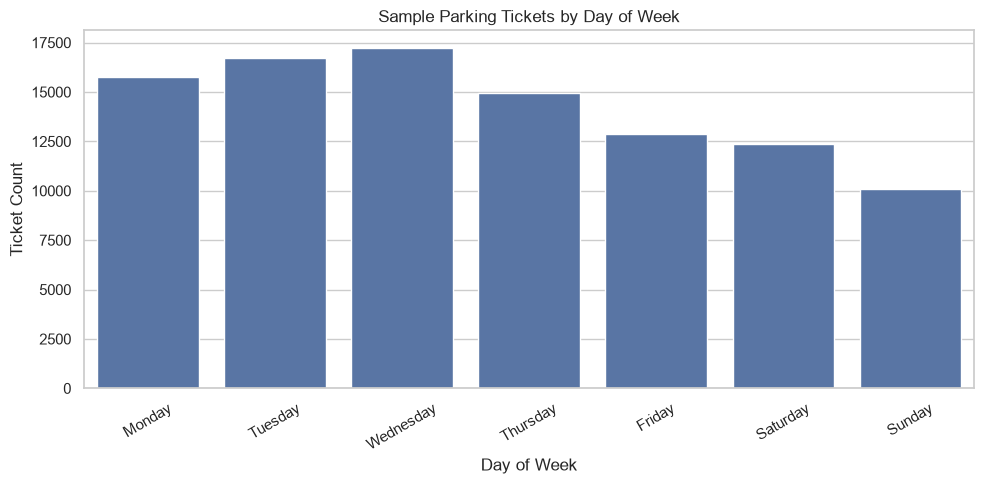

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=clean_sample, x="issue_day_name", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Sample Parking Tickets by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Ticket Count")
plt.xticks(rotation=30)
plt.tight_layout()

## Step 8: Clean the full source file in chunks

The full file is too large to casually process in memory. The function below reads the source file in chunks, cleans each chunk, removes duplicate summons numbers across chunks, and appends each cleaned chunk to `data/processed/parking_clean.csv`.

This cell may take several minutes to run because the original file has more than 7 million rows.

In [ ]:
def clean_full_parking_file(raw_path: Path, output_path: Path, chunksize: int = 100_000) -> dict[str, int]:
    """Clean the full parking file in chunks and write a reproducible processed CSV."""
    output_path.parent.mkdir(parents=True, exist_ok=True)

    seen_summons: set[int] = set()
    total_read = 0
    total_written = 0
    total_invalid_or_removed = 0
    duplicate_removed = 0
    first_chunk = True

    for chunk_number, chunk in enumerate(
        pd.read_csv(raw_path, usecols=list(SOURCE_COLUMNS), chunksize=chunksize, low_memory=False, dtype=str),
        start=1,
    ):
        total_read += len(chunk)
        cleaned = clean_parking_chunk(chunk)
        total_invalid_or_removed += len(chunk) - len(cleaned)

        rows_before_deduplication = len(cleaned)
        cleaned = cleaned.drop_duplicates(subset=["summons_number"], keep="first")
        duplicate_mask = cleaned["summons_number"].isin(seen_summons)
        cleaned = cleaned.loc[~duplicate_mask].copy()
        duplicate_removed += rows_before_deduplication - len(cleaned)
        seen_summons.update(cleaned["summons_number"].tolist())

        cleaned.to_csv(output_path, mode="w" if first_chunk else "a", index=False, header=first_chunk)
        total_written += len(cleaned)
        first_chunk = False

        print(f"Chunk {chunk_number}: read {total_read:,}, written {total_written:,}")

    return {
        "rows_read": total_read,
        "rows_written": total_written,
        "rows_removed_invalid_or_missing_required": total_invalid_or_removed,
        "duplicate_summons_removed": duplicate_removed,
    }

Run the next cell when you are ready to build the full cleaned file. It is intentionally separate so the notebook can be reviewed without accidentally reprocessing the full 1+ GB source file.

In [ ]:
# Uncomment and run this cell to create the cleaned parking CSV.
# cleaning_summary = clean_full_parking_file(RAW_FILE, CLEAN_FILE)
# cleaning_summary

## Step 9: Validate the cleaned output

After the full cleaning process runs, the cleaned file should be validated. These checks confirm that the output exists, has the expected columns, and can be used for the next phase of the project.

In [ ]:
if CLEAN_FILE.exists():
    cleaned_rows = count_csv_rows(CLEAN_FILE)
    cleaned_header = read_csv_header(CLEAN_FILE)
    print(f"Cleaned file: {CLEAN_FILE}")
    print(f"Cleaned rows: {cleaned_rows:,}")
    print(f"Cleaned columns: {len(cleaned_header)}")
    display(pd.read_csv(CLEAN_FILE, nrows=5))
else:
    print("Cleaned file has not been created yet. Run the full cleaning cell above when ready.")

Cleaned file: c:\Users\jayson.coker\Documents\nyc-parking-analytics\data\processed\parking_clean.csv
Cleaned rows: 7,056,788
Cleaned columns: 22


,summons_number,plate_id,registration_state,plate_type,issue_date,violation_code,vehicle_body_type,vehicle_make,issuing_agency,violation_precinct,issuer_precinct,violation_time,violation_county,street_name,vehicle_color,vehicle_year,violation_description,issue_year,issue_month,issue_day_of_week,issue_day_name,borough
0,9139716661,LKS7820,NY,PAS,2024-07-02,38,SUBN,TOYOT,T,5,5,0209P,NY,Mott St,WH,2024,38-Failure to Dsplay Meter Rec,2024,7,1,Tuesday,Manhattan
1,4903865265,Y23UMS,NJ,PAS,2024-06-21,36,VAN,ME/BE,V,0,0,1009A,BK,NB UTICA AVE @ AVE L,NaN,2024,PHTO SCHOOL ZN SPEED VIOLATION,2024,6,4,Friday,Brooklyn
2,9140510268,N76NJN,NJ,PAS,2024-07-08,14,SUBN,HYUND,T,18,18,0325P,NY,Lexington Ave,WHITE,0,14-No Standing,2024,7,0,Monday,Manhattan
3,9136561575,42UD91,NY,MCL,2024-07-12,71,MCY,HONDA,T,79,79,0939A,K,Hancock St,BLACK,0,71A-Insp Sticker Expired (NYS),2024,7,4,Friday,Brooklyn
4,9139621832,76925NE,NY,COM,2024-07-11,14,VAN,ISUZU,T,103,103,1116A,Q,Jamaica Ave,WH,2018,14-No Standing,2024,7,3,Thursday,Queens


## Step 10: Review the unique county values

Before relying on `violation_county` for borough analysis, I check every unique value in the cleaned file. This shows that the source uses several abbreviations and inconsistent spellings for the same locations. These differences explain why a standardized `borough` column is needed.

In [ ]:
unique_counties = set()

for chunk in pd.read_csv(
    CLEAN_FILE,
    usecols=["violation_county"],
    dtype="string",
    chunksize=250_000,
):
    county_values = chunk["violation_county"].dropna().str.strip().unique()
    unique_counties.update(county_values)

unique_counties = sorted(value for value in unique_counties if value)

print(f"Unique non-null county values: {len(unique_counties)}")
print(unique_counties)

Unique non-null county values: 18
['108', 'BK', 'BRONX', 'BX', 'Bronx', 'K', 'K   F', 'Kings', 'MN', 'NY', 'P', 'Q', 'QN', 'QNS', 'Qns', 'R', 'Rich', 'ST']


## Step 11: Cleaning conclusions

This notebook creates an analysis-ready parking violations dataset from the original NYC parking source file. The cleaned dataset is designed for:

- SQLite loading,
- time-based analysis,
- violation type analysis,
- precinct and borough analysis,
- joins to weather by date,
- joins to violation fine lookup by violation code,
- joins to census context by borough or county.

The next project step is to create the SQLite database and load the cleaned parking data, weather data, fine lookup, and census data into relational tables.

## Holding space for Street Code API project## 

In [ ]:
# Input and output file locations
raw_file = Path("../data/raw/nycparking2025.csv")
output_file = Path("../data/processed/parking_locations.csv")

# Columns to extract
location_columns = [
    "Summons Number",
    "Issue Date",
    "Street Code1",
    "Street Code2",
    "Street Code3",
    "Violation Location",
    "Violation Precinct",
    "Violation County",
    "Street Name",
]

# Create the output directory if necessary
output_file.parent.mkdir(parents=True, exist_ok=True)

chunk_size = 100_000
first_chunk = True
total_rows = 0

for chunk_number, location_df in enumerate(
    pd.read_csv(
        raw_file,
        usecols=location_columns,
        dtype="string",
        chunksize=chunk_size,
        low_memory=False,
    ),
    start=1,
):
    # Write the first chunk with column headers.
    # Later chunks are appended without repeating the headers.
    location_df.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False,
    )

    first_chunk = False
    total_rows += len(location_df)

    print(
        f"Chunk {chunk_number}: "
        f"{len(location_df):,} rows saved; "
        f"{total_rows:,} total rows"
    )

print(f"\nFinished saving {total_rows:,} rows to:")
print(output_file.resolve())

# Preview the final chunk processed
display(location_df.head())

Chunk 1: 100,000 rows saved; 100,000 total rows
Chunk 2: 100,000 rows saved; 200,000 total rows
Chunk 3: 100,000 rows saved; 300,000 total rows
Chunk 4: 100,000 rows saved; 400,000 total rows
Chunk 5: 100,000 rows saved; 500,000 total rows
Chunk 6: 100,000 rows saved; 600,000 total rows
Chunk 7: 100,000 rows saved; 700,000 total rows
Chunk 8: 100,000 rows saved; 800,000 total rows
Chunk 9: 100,000 rows saved; 900,000 total rows
Chunk 10: 100,000 rows saved; 1,000,000 total rows
Chunk 11: 100,000 rows saved; 1,100,000 total rows
Chunk 12: 100,000 rows saved; 1,200,000 total rows
Chunk 13: 100,000 rows saved; 1,300,000 total rows
Chunk 14: 100,000 rows saved; 1,400,000 total rows
Chunk 15: 100,000 rows saved; 1,500,000 total rows
Chunk 16: 100,000 rows saved; 1,600,000 total rows
Chunk 17: 100,000 rows saved; 1,700,000 total rows
Chunk 18: 100,000 rows saved; 1,800,000 total rows
Chunk 19: 100,000 rows saved; 1,900,000 total rows
Chunk 20: 100,000 rows saved; 2,000,000 total rows
Chunk 2

,Summons Number,Issue Date,Street Code1,Street Code2,Street Code3,Violation Location,Violation Precinct,Violation County,Street Name
7000000,1498468512,10/15/2024,0,40404,40404,49,49,BX,PELHAM PKW SOUTH
7000001,4924685770,11/04/2024,0,0,0,<NA>,0,QN,NB 81ST ST @ 21ST AV
7000002,4923906467,10/30/2024,0,0,0,<NA>,0,BK,SB ROCKAWAY PKWY @ S
7000003,9172789293,11/23/2024,72230,18630,73690,71,71,K,President St
7000004,9166346794,11/07/2024,52050,16090,16190,112,112,Q,Kew Forest Ln


In [ ]:
sample[["Street Code1", "Street Code2", "Street Code3"]].head(500)

,Street Code1,Street Code2,Street Code3
0,26790,28590,12810
1,0,40404,40404
2,24890,17910,17930
3,47030,58730,85730
4,51090,64790,23070
...,...,...,...
495,0,0,0
496,0,0,0
497,0,13495,0
498,13610,37190,37210


In [ ]:
borough_codes = {
    "NY": "1",  # Manhattan
    "MN": "1",
    "BX": "2",  # Bronx
    "K":  "3",  # Brooklyn
    "BK": "3",
    "Q":  "4",  # Queens
    "QN": "4",
    "R":  "5",  # Staten Island
    "ST": "5",
}

sample["borough_code"] = sample["Violation County"].map(borough_codes)

for column in ["Street Code1", "Street Code2", "Street Code3"]:
    sample[f"{column}_B5SC"] = (
        sample["borough_code"]
        + sample[column].astype("string").str.zfill(5)
    ).where(sample[column] != "0")

sample[
    [
        "Street Name",
        "Violation County",
        "Street Code1_B5SC",
        "Street Code2_B5SC",
        "Street Code3_B5SC",
    ]
].head(20)

,Street Name,Violation County,Street Code1_B5SC,Street Code2_B5SC,Street Code3_B5SC
0,Mott St,NY,126790,128590,112810
1,NB UTICA AVE @ AVE L,BK,<NA>,340404,340404
2,Lexington Ave,NY,124890,117910,117930
3,Hancock St,K,347030,358730,385730
4,Jamaica Ave,Q,451090,464790,423070
5,WASHINGTON,NY,<NA>,140404,140404
6,NB OCEAN AVE @ FARRA,BK,<NA>,<NA>,<NA>
7,NB Webster Ave @ E 1,NaN,<NA>,<NA>,<NA>
8,SB BLOOMINGDALE RD @,ST,<NA>,<NA>,<NA>
9,EB QUEENS BLVD @ 72N,QN,<NA>,<NA>,<NA>


In [ ]:

BOROUGH_CODES = {
    "NY": "1",
    "MN": "1",
    "BX": "2",
    "K": "3",
    "BK": "3",
    "Q": "4",
    "QN": "4",
    "R": "5",
    "ST": "5",
}


def format_goat_street_codes(row):
    """Return valid Street Code1–3 values formatted as B5SC codes."""
    borough = BOROUGH_CODES.get(str(row["Violation County"]).strip().upper())

    if borough is None:
        return []

    goat_codes = []

    for column in ["Street Code1", "Street Code2", "Street Code3"]:
        value = pd.to_numeric(row[column], errors="coerce")

        # Skip missing values and zero.
        if pd.isna(value) or value == 0:
            continue

        # Borough digit + five-digit street code.
        goat_codes.append(f"{borough}{int(value):05d}")

    return goat_codes

In [ ]:
sample["goat_street_codes"] = sample.apply(
    format_goat_street_codes,
    axis=1
)

sample[
    [
        "Violation County",
        "Street Code1",
        "Street Code2",
        "Street Code3",
        "goat_street_codes",
    ]
].head(20)

,Violation County,Street Code1,Street Code2,Street Code3,goat_street_codes
0,NY,26790,28590,12810,"[126790, 128590, 112810]"
1,BK,0,40404,40404,"[340404, 340404]"
2,NY,24890,17910,17930,"[124890, 117910, 117930]"
3,K,47030,58730,85730,"[347030, 358730, 385730]"
4,Q,51090,64790,23070,"[451090, 464790, 423070]"
5,NY,0,40404,40404,"[140404, 140404]"
6,BK,0,0,0,[]
7,NaN,0,0,0,[]
8,ST,0,0,0,[]
9,QN,0,0,0,[]


In [ ]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/geosupport_borough_matches.csv",
    dtype=str
).fillna("")

df[df["status"] == "ambiguous"].to_csv("ambiguous.csv", index=False)
df[df["status"] == "review"].to_csv("review.csv", index=False)
df[df["status"] == "unmatched"].to_csv("unmatched.csv", index=False)

In [ ]:
from functools import lru_cache
from pathlib import Path
import logging
import re

import pandas as pd
from geosupport import Geosupport
from geosupport.error import GeosupportError


# Locate the project root whether running from the root or notebooks folder.
cwd = Path.cwd()
project_root = next(
    root
    for root in (cwd, *cwd.parents)
    if (root / "data" / "processed" / "geosupport_borough_matches.csv").exists()
)

input_file = (
    project_root
    / "data"
    / "processed"
    / "geosupport_borough_matches.csv"
)

output_file = (
    project_root
    / "data"
    / "processed"
    / "ambiguous_reprocessed.csv"
)

geosupport_path = (
    Path.home()
    / "AppData"
    / "Local"
    / "Programs"
    / "Geosupport Desktop Edition"
)

borough_codes = {
    "Manhattan": 1,
    "Bronx": 2,
    "Brooklyn": 3,
    "Queens": 4,
    "Staten Island": 5,
}


# Suppress expected rejection messages.
for logger_name in ("geosupport", "geosupport.geosupport"):
    logger = logging.getLogger(logger_name)
    logger.disabled = True
    logger.propagate = False

geo = Geosupport(geosupport_path=str(geosupport_path))


def parse_camera_description(value):
    """Extract on-street and cross-street from descriptions such as
    'SB Melrose Ave @ E 161 St'.
    """
    text = str(value or "").strip().upper()
    text = re.sub(r"\s+", " ", text)

    # Remove travel-direction prefixes.
    text = re.sub(
        r"^(NB|SB|EB|WB|N/B|S/B|E/B|W/B)\s+",
        "",
        text,
    )

    if "@" in text:
        on_street, cross_street = text.split("@", 1)
    else:
        on_street, cross_street = text, ""

    return on_street.strip(), cross_street.strip()


def successful(result):
    code = str(result.get("Geosupport Return Code (GRC)", "")).strip()
    return code.isdigit() and int(code) <= 1


@lru_cache(maxsize=None)
def function_1n(borough, street):
    """Test whether a street name exists in a borough."""
    if not street:
        return False

    try:
        result = geo["1N"](
            borough=borough_codes[borough],
            street_name=street,
        )
        return successful(result)
    except GeosupportError:
        return False


@lru_cache(maxsize=None)
def function_2(borough, street1, street2):
    """Test whether two streets form an actual intersection."""
    if not street1 or len(street2) < 3:
        return False

    try:
        result = geo["2"](
            borough=borough_codes[borough],
            street_name=street1,
            street_name_2=street2,
            cross_street_names=True,
        )
        return successful(result)
    except GeosupportError:
        return False


def review_ambiguous_row(row):
    on_street, cross_street = parse_camera_description(
        row["source_street_name"]
    )

    candidate_boroughs = [
        value
        for value in row["display_valid_boroughs"].split("|")
        if value
    ]

    name_matches = [
        borough
        for borough in candidate_boroughs
        if function_1n(borough, on_street)
    ]

    intersection_matches = [
        borough
        for borough in candidate_boroughs
        if function_2(borough, on_street, cross_street)
    ]

    if len(intersection_matches) == 1:
        suggestion = intersection_matches[0]
        confidence = "high"
        method = "parsed_intersection_function_2"
    elif len(name_matches) == 1:
        suggestion = name_matches[0]
        confidence = "medium"
        method = "parsed_street_function_1n"
    else:
        suggestion = ""
        confidence = ""
        method = "still_ambiguous"

    return pd.Series(
        {
            "parsed_on_street": on_street,
            "parsed_cross_street": cross_street,
            "name_valid_boroughs": "|".join(name_matches),
            "intersection_valid_boroughs": "|".join(
                intersection_matches
            ),
            "review_suggested_borough": suggestion,
            "review_confidence": confidence,
            "review_method": method,
        }
    )


df = pd.read_csv(input_file, dtype=str).fillna("")
ambiguous = df.loc[df["status"].eq("ambiguous")].copy()

review_results = ambiguous.apply(review_ambiguous_row, axis=1)
ambiguous = pd.concat([ambiguous, review_results], axis=1)

ambiguous.to_csv(output_file, index=False)

print(f"Input ambiguous rows: {len(ambiguous):,}")
print()
print(ambiguous["review_method"].value_counts())
print()
print(f"Saved to: {output_file}")

Input ambiguous rows: 2,841

review_method
parsed_street_function_1n    2452
still_ambiguous               389
Name: count, dtype: int64

Saved to: c:\Users\jayson.coker\Documents\nyc-parking-analytics\data\processed\ambiguous_reprocessed.csv
